In [5]:
import os
from dotenv import load_dotenv
import pandas as pd
from sqlalchemy import create_engine, text
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set pandas display options
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

### loads `.env`
#### Setting up the `database connection`

In [6]:
load_dotenv()

pg_url = (
    f"postgresql+psycopg2://{os.getenv('PGUSER')}:{os.getenv('PGPASSWORD')}"
    f"@{os.getenv('PGHOST')}:{os.getenv('PGPORT')}/{os.getenv('PGDATABASE')}"
)

engine = create_engine(pg_url, pool_pre_ping=True)

with engine.begin() as conn:
    conn.execute(text("SET search_path TO mart, curated, public;"))

with engine.begin() as conn:
    print(conn.execute(text("SELECT now()")).scalar())

2025-11-27 15:14:40.475357-05:00


`38% (~212796)` fraudulent claims detected out of `558211` total claims
- `IP - 23402` (~11%) fraudulent records<br>
- `OP - 189394` (~89%) fraudulent records

#### 4 -  `HDBSCAN clustering` of fraudulent claims (IP & OP)

#### 4.1 Validate HDBSCAN clusters (DBCV + ARI)

In [ ]:
# ===== HDBSCAN re-tune for lower noise & better DBCV (IP & OP) =====
# Paste this in a NEW cell right after your DB connection (`engine`) is defined.

import numpy as np
import pandas as pd
import warnings
from sklearn.preprocessing import RobustScaler
import hdbscan
from hdbscan.validity import validity_index  # DBCV
from datetime import datetime

warnings.filterwarnings("ignore", category=RuntimeWarning)

# --------------------------
# 1) Load fraud-only claims
# --------------------------
ip_raw = pd.read_sql("SELECT * FROM mart.fraud_claims_ip", con=engine)
op_raw = pd.read_sql("SELECT * FROM mart.fraud_claims_op", con=engine)

# --------------------------
# 2) Strong preprocessing
#    - numeric cast
#    - log1p on reimburse
#    - deductible_share
#    - drop constant cols
#    - RobustScaler
#    - drop duplicate rows (avoids zero distances)
#    - tiny jitter before DBCV
# --------------------------


def build_matrix_strong(df, claim_type):
    if claim_type == "IP":
        feats = ["reimb_amt", "deductible_paid", "dx_count", "px_count", "los_days",
                 "z_ip_reimb", "z_ip_los", "dup_exact_flag", "dup_near_count",
                 "overcharge_z_flag", "overcharge_iqr_flag"]
    else:
        feats = ["reimb_amt", "deductible_paid", "dx_count", "px_count",
                 "z_op_reimb", "dup_exact_flag", "dup_near_count",
                 "overcharge_z_flag", "overcharge_iqr_flag"]

    X = df[feats].apply(pd.to_numeric, errors="coerce").copy()
    # engineer robust $ features
    X["reimb_amt_log"] = np.log1p(X["reimb_amt"].clip(lower=0))
    denom = df["reimb_amt"].replace(0, np.nan)
    X["deductible_share"] = (df["deductible_paid"] / denom).clip(0, 5)

    # drop raw $ after deriving
    X = X.drop(
        columns=[c for c in ["reimb_amt", "deductible_paid"] if c in X.columns])

    # drop constant cols (zero variance -> zero distances)
    nunq = X.nunique(dropna=True)
    keep_cols = nunq[nunq > 1].index.tolist()
    X = X[keep_cols]

    # fill NA with medians; robust scale
    X = X.fillna(X.median(numeric_only=True))
    Xs = RobustScaler().fit_transform(X)  # robust to outliers (median/IQR)

    # drop duplicate rows in scaled space (avoid exact zero distances)
    Xs_df = pd.DataFrame(Xs, columns=keep_cols, index=df.index)
    Xs_df = Xs_df[~Xs_df.duplicated(keep="first")]
    df_clean = df.loc[Xs_df.index].copy()

    # tiny jitter to be extra-safe for DBCV numerical ops
    rng = np.random.RandomState(42)
    Xs_jitter = Xs_df.values + 1e-9 * rng.normal(size=Xs_df.shape)

    return df_clean, Xs_jitter, keep_cols


ip_df, Xs_ip, cols_ip = build_matrix_strong(ip_raw, "IP")
op_df, Xs_op, cols_op = build_matrix_strong(op_raw, "OP")

# --------------------------
# 3) Auto-tune HDBSCAN
#    - search small grids over min_cluster_size (% of n), min_samples,
#      cluster_selection_method ('leaf','eom'), and metric
#    - prefer higher DBCV, then lower noise, then more clusters
#    - only compute DBCV if >=2 clusters (else set to -inf)
# --------------------------


def pct(n, p):
    return max(10, int(np.ceil(n * p)))


def tune_hdbscan(Xs, min_cluster_size_grid, min_samples_grid,
                 methods=("leaf", "eom"), metrics=("euclidean", "manhattan")):
    best = {"dbcv": -np.inf}
    n = Xs.shape[0]
    for mcs in min_cluster_size_grid:
        for ms in min_samples_grid:
            for method in methods:
                for metric in metrics:
                    clus = hdbscan.HDBSCAN(min_cluster_size=mcs,
                                           min_samples=ms,
                                           cluster_selection_method=method,
                                           metric=metric,
                                           prediction_data=True)
                    labels = clus.fit_predict(Xs)
                    k = len(set(labels)) - (1 if -1 in labels else 0)
                    noise = float((labels == -1).mean())
                    if k >= 2:
                        try:
                            dbcv = float(validity_index(Xs, labels))
                        except Exception:
                            dbcv = -np.inf
                    else:
                        dbcv = -np.inf
                    score_tuple = (dbcv, -noise, k)
                    if score_tuple > (best["dbcv"], -best.get("noise", 1.0), best.get("k", 0)):
                        best.update({
                            "dbcv": dbcv, "noise": noise, "k": int(k),
                            "min_cluster_size": mcs, "min_samples": ms,
                            "method": method, "metric": metric,
                            "labels": labels, "model": clus
                        })
    return best


grid_ip = {"mcs": [pct(Xs_ip.shape[0], p) for p in (0.01, 0.015, 0.02)],
           "ms":  [5, 7, 10]}
grid_op = {"mcs": [pct(Xs_op.shape[0], p) for p in (0.01, 0.015, 0.02)],
           "ms":  [5, 7, 10]}

best_ip = tune_hdbscan(Xs_ip, grid_ip["mcs"], grid_ip["ms"])
best_op = tune_hdbscan(Xs_op, grid_op["mcs"], grid_op["ms"])

print("Best IP params:",
      {k: best_ip[k] for k in ["dbcv", "noise", "k", "min_cluster_size", "min_samples", "method", "metric"]})
print("Best OP params:",
      {k: best_op[k] for k in ["dbcv", "noise", "k", "min_cluster_size", "min_samples", "method", "metric"]})

# attach labels to cleaned frames
ip = ip_df.copy()
ip["cluster"] = best_ip["labels"]
op = op_df.copy()
op["cluster"] = best_op["labels"]

# --------------------------
# 4) Persist results to DB
#    - log a small run record with chosen params
# --------------------------
ip_out_table = "fraud_claims_ip_clusters"
op_out_table = "fraud_claims_op_clusters"

# keep original columns + cluster
ip.to_sql(ip_out_table, con=engine, schema="mart",
          index=False, if_exists="replace")
op.to_sql(op_out_table, con=engine, schema="mart",
          index=False, if_exists="replace")

runlog = pd.DataFrame([{
    "run_ts": datetime.utcnow().isoformat(),
    "table_in_ip": "mart.fraud_claims_ip",
    "table_in_op": "mart.fraud_claims_op",
    "table_out_ip": f"mart.{ip_out_table}",
    "table_out_op": f"mart.{op_out_table}",
    "ip_dbcv": best_ip["dbcv"], "ip_noise": best_ip["noise"], "ip_k": best_ip["k"],
    "ip_min_cluster_size": best_ip["min_cluster_size"], "ip_min_samples": best_ip["min_samples"],
    "ip_method": best_ip["method"], "ip_metric": best_ip["metric"],
    "op_dbcv": best_op["dbcv"], "op_noise": best_op["noise"], "op_k": best_op["k"],
    "op_min_cluster_size": best_op["min_cluster_size"], "op_min_samples": best_op["min_samples"],
    "op_method": best_op["method"], "op_metric": best_op["metric"]
}])

# runlog.to_sql("hdbscan_runs", con=engine, schema="mart",
#               index=False, if_exists="append")

print("\nWrote:")
print(f"  mart.{ip_out_table}  (rows={len(ip)})")
print(f"  mart.{op_out_table}  (rows={len(op)})")
print("  mart.hdbscan_runs    (+1 row)")

c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 

Best IP params: {'dbcv': 0.1296742408195641, 'noise': 0.31559187279151946, 'k': 19, 'min_cluster_size': 340, 'min_samples': 10, 'method': 'leaf', 'metric': 'manhattan'}
Best OP params: {'dbcv': 0.18808329243753363, 'noise': 0.155209324452902, 'k': 11, 'min_cluster_size': 127, 'min_samples': 7, 'method': 'eom', 'metric': 'manhattan'}

Wrote:
  mart.fraud_claims_ip_clusters  (rows=22640)
  mart.fraud_claims_op_clusters  (rows=8408)
  mart.hdbscan_runs    (+1 row)

Wrote:
  mart.fraud_claims_ip_clusters  (rows=22640)
  mart.fraud_claims_op_clusters  (rows=8408)
  mart.hdbscan_runs    (+1 row)


C:\Users\zayed\AppData\Local\Temp\ipykernel_44212\803481024.py:157: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "run_ts": datetime.utcnow().isoformat(),


#### 4.2 — Cluster cards (fraudulent IP & OP claims)

Saved cluster cards -> fraud_ip_cluster_cards.csv, fraud_op_cluster_cards.csv


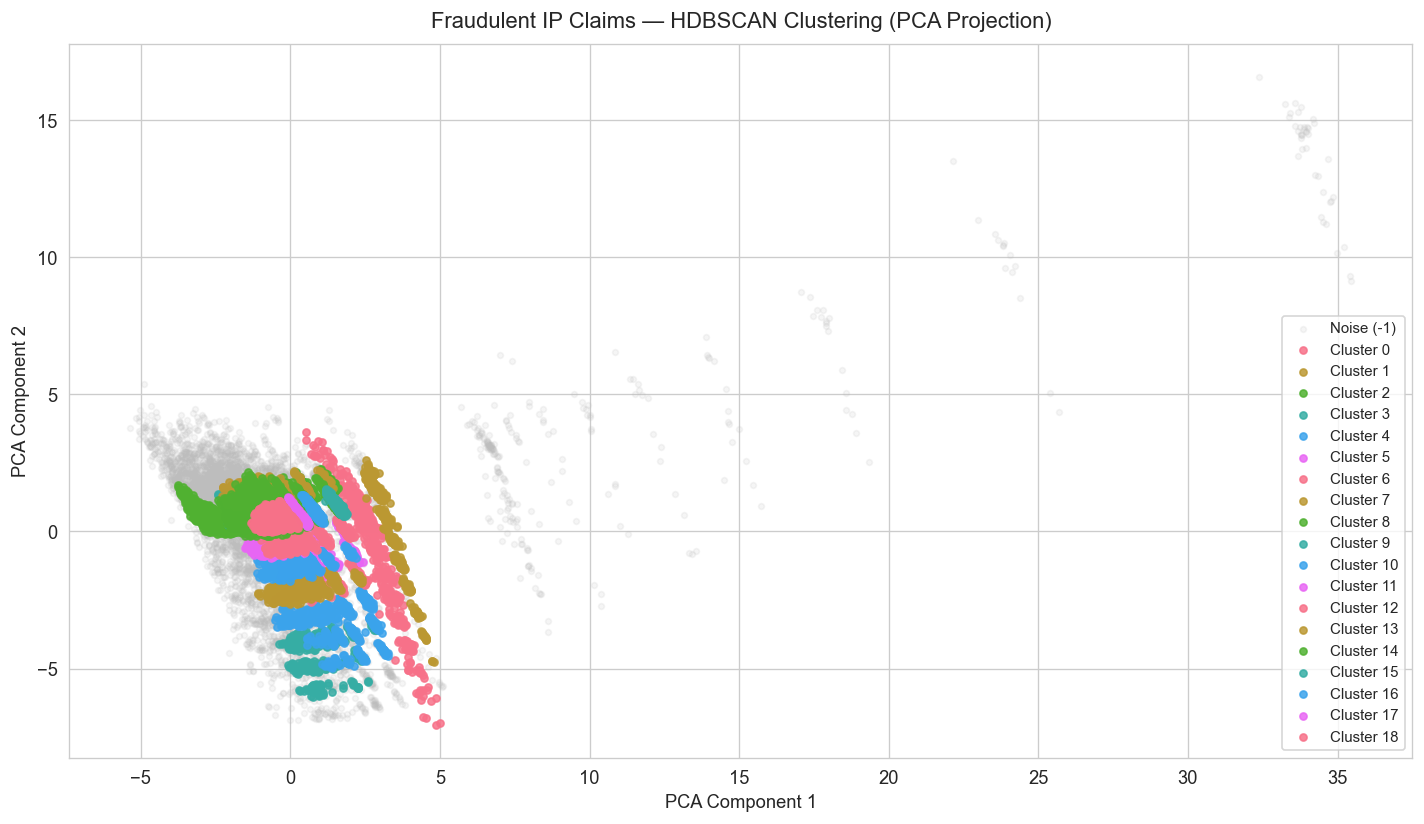

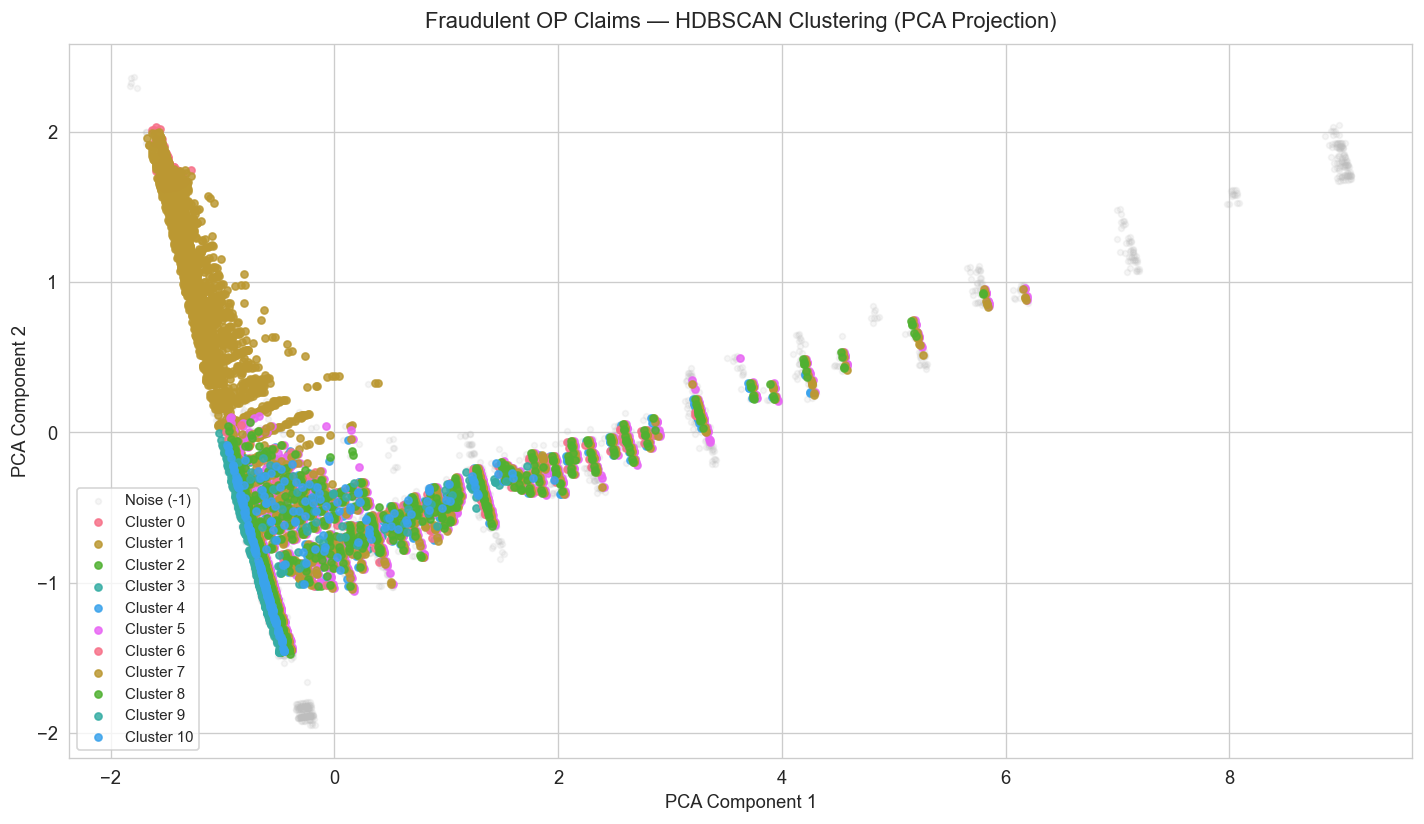

IP PCA variance explained (2D): 0.625
OP PCA variance explained (2D): 0.874


In [25]:
# ===== Step 4.2 — Cluster Cards + PCA Scatter Maps (IP & OP) =====
# Paste this in a NEW cell after your DB connection (`engine`) is defined.

import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# 1) Load the clustered fraud-only claims written by your tuning step
# -------------------------------------------------------------------
ip = pd.read_sql("SELECT * FROM mart.fraud_claims_ip_clusters", con=engine)
op = pd.read_sql("SELECT * FROM mart.fraud_claims_op_clusters", con=engine)

# -------------------------------------------------------------------
# 2) Cluster cards (exclude noise = -1)
#    - n, total_paid, median_paid
#    - robust medians of interpretable features per cluster
# -------------------------------------------------------------------


def _present(cols, df):
    return [c for c in cols if c in df.columns]


def make_cluster_cards(df, claim_type):
    core = df[df["cluster"] != -1].copy()
    if core.empty:
        return pd.DataFrame()

    money = core.groupby("cluster")["reimb_amt"].agg(
        n="count", total_paid="sum", median_paid="median"
    )

    base_feats = ["dx_count", "px_count", "dup_exact_flag", "dup_near_count",
                  "overcharge_z_flag", "overcharge_iqr_flag"]
    if claim_type == "IP":
        base_feats += ["los_days", "z_ip_reimb", "z_ip_los"]
    else:
        base_feats += ["z_op_reimb"]

    feat_cols = _present(base_feats, core)
    stats = core.groupby("cluster")[feat_cols].median(numeric_only=True)
    cards = (money.join(stats)
                  .reset_index()
                  .sort_values(["n", "total_paid"], ascending=[False, False]))
    return cards


ip_cards = make_cluster_cards(ip, "IP")
op_cards = make_cluster_cards(op, "OP")

ip_cards.to_csv("fraud_ip_cluster_cards.csv", index=False)
op_cards.to_csv("fraud_op_cluster_cards.csv", index=False)
print("Saved cluster cards -> fraud_ip_cluster_cards.csv, fraud_op_cluster_cards.csv")

# -------------------------------------------------------------------
# 3) PCA scatter maps (noise in light gray, clusters colored)
#    PCA is a linear projection to 2D for VISUALIZATION ONLY.  :contentReference[oaicite:3]{index=3}
#    Features are RobustScaled (median/IQR) to handle heavy tails.  :contentReference[oaicite:4]{index=4}
# -------------------------------------------------------------------


def build_matrix_for_pca(df, claim_type):
    # match the tuning features (with $ transforms)
    if claim_type == "IP":
        feats = ["reimb_amt", "deductible_paid", "dx_count", "px_count", "los_days",
                 "z_ip_reimb", "z_ip_los", "dup_exact_flag", "dup_near_count",
                 "overcharge_z_flag", "overcharge_iqr_flag"]
    else:
        feats = ["reimb_amt", "deductible_paid", "dx_count", "px_count",
                 "z_op_reimb", "dup_exact_flag", "dup_near_count",
                 "overcharge_z_flag", "overcharge_iqr_flag"]

    X = df[_present(feats, df)].apply(pd.to_numeric, errors="coerce").copy()

    # Derive log$ & deductible share, then drop raw $ columns
    if "reimb_amt" in X.columns:
        X["reimb_amt_log"] = np.log1p(X["reimb_amt"].clip(lower=0))
    if "deductible_paid" in X.columns and "reimb_amt" in df.columns:
        denom = df["reimb_amt"].replace(0, np.nan)
        X["deductible_share"] = (df["deductible_paid"] / denom).clip(0, 5)

    X = X.drop(
        columns=[c for c in ["reimb_amt", "deductible_paid"] if c in X.columns])

    # Drop constant columns, fill NA with medians, Robust scale
    nunq = X.nunique(dropna=True)
    keep = nunq[nunq > 1].index.tolist()
    if not keep:
        raise ValueError(
            "All features constant/empty after filtering; cannot plot PCA.")
    X = X[keep].fillna(X.median(numeric_only=True))

    # centers by median, scales by IQR  :contentReference[oaicite:5]{index=5}
    Xs = RobustScaler().fit_transform(X)
    return Xs


def pca_2d(Xs):
    # linear projection to 2D  :contentReference[oaicite:6]{index=6}
    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(Xs)
    return Z, pca.explained_variance_ratio_.sum()


def plot_pca_scatter(Z, labels, title, fname):
    labels = np.asarray(labels)
    uniq = np.unique(labels)

    plt.figure(figsize=(12, 7), dpi=120)

    # Plot noise (-1) first in light gray for context
    noise_mask = labels == -1
    if noise_mask.any():
        plt.scatter(Z[noise_mask, 0], Z[noise_mask, 1],
                    s=12, alpha=0.15, c="#bdbdbd", label="Noise (-1)")

    # Plot each cluster on top; let Matplotlib choose colors
    for c in uniq:
        if c == -1:
            continue
        m = labels == c
        plt.scatter(Z[m, 0], Z[m, 1], s=18, alpha=0.85, label=f"Cluster {c}")

    plt.title(title, pad=10)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend(loc="best", fontsize=9, frameon=True)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches="tight")
    plt.show()


# IP
Xs_ip = build_matrix_for_pca(ip, "IP")
Z_ip, ip_var = pca_2d(Xs_ip)
plot_pca_scatter(Z_ip, ip["cluster"].to_numpy(),
                 "Fraudulent IP Claims — HDBSCAN Clustering (PCA Projection)",
                 "fraudulent_ip_claims_pca.png")

# OP
Xs_op = build_matrix_for_pca(op, "OP")
Z_op, op_var = pca_2d(Xs_op)
plot_pca_scatter(Z_op, op["cluster"].to_numpy(),
                 "Fraudulent OP Claims — HDBSCAN Clustering (PCA Projection)",
                 "fraudulent_op_claims_pca.png")

print(f"IP PCA variance explained (2D): {ip_var:.3f}")
print(f"OP PCA variance explained (2D): {op_var:.3f}")

#### 4.3 - mine association rules (dx/px patterns) inside each HDBSCAN cluster

In [29]:
import pandas as pd
import numpy as np
# Apriori & rule metrics  :contentReference[oaicite:5]{index=5}
from mlxtend.frequent_patterns import apriori, association_rules

# 1) Load clustered fraud-only claims (created in 4.1) and normalized codes
ip = pd.read_sql(
    "SELECT claimid, cluster FROM mart.fraud_claims_ip_clusters", con=engine)
op = pd.read_sql(
    "SELECT claimid, cluster FROM mart.fraud_claims_op_clusters", con=engine)
codes = pd.read_sql(
    "SELECT claimid, item FROM mart.claim_codes", con=engine).drop_duplicates()

# 2) Helper: mine rules within each cluster of a given dataframe (ip or op)


def mine_rules_by_cluster(df_claims, claim_type, min_support=0.02, min_conf=0.6, min_lift=1.2, top_items=300):
    # Join cluster labels to codes (exclude noise = -1)
    cc = df_claims[df_claims["cluster"] != -
                   1].merge(codes, on="claimid", how="inner")
    results = []

    # Loop over clusters
    for c in sorted(cc["cluster"].unique()):
        sub = cc[cc["cluster"] == c][["claimid", "item"]].drop_duplicates()

        # Optional: restrict to most common items for tractability
        popular = sub["item"].value_counts().head(top_items).index
        sub = sub[sub["item"].isin(popular)]

        # One-hot encode: transactions x items (bool)
        basket = pd.crosstab(sub["claimid"], sub["item"]).astype(bool)

        # Dynamic min_support: ensure at least ~30 claims for antecedent coverage if cluster is small
        ms = max(min_support, 30 / max(1, basket.shape[0]))

        # Apriori frequent itemsets
        # frequent itemsets  :contentReference[oaicite:6]{index=6}
        itemsets = apriori(basket, min_support=ms, use_colnames=True)
        if itemsets.empty:
            continue

        # Association rules with confidence & lift  :contentReference[oaicite:7]{index=7}
        rules = association_rules(
            itemsets, metric="confidence", min_threshold=min_conf)
        if rules.empty:
            continue

        # Filter by lift (strength above chance) and sort  :contentReference[oaicite:8]{index=8}
        rules = rules[rules["lift"] >= min_lift].copy()
        if rules.empty:
            continue

        # Add convenience columns
        n_claims = basket.shape[0]
        rules["cluster"] = c
        rules["claim_type"] = claim_type
        rules["n_in_cluster"] = n_claims
        # Convert frozensets to readable strings
        rules["antecedents_str"] = rules["antecedents"].apply(
            lambda s: "+".join(sorted(map(str, s))))
        rules["consequents_str"] = rules["consequents"].apply(
            lambda s: "+".join(sorted(map(str, s))))
        # Coverage counts inside the cluster
        rules["antecedent_cov"] = (
            rules["support"] * n_claims).round().astype(int)

        # Keep tidy columns
        keep = ["claim_type", "cluster", "n_in_cluster", "antecedents_str", "consequents_str",
                "support", "confidence", "lift", "antecedent_cov"]
        results.append(rules[keep].sort_values(
            ["lift", "support"], ascending=False))

    if not results:
        return pd.DataFrame(columns=["claim_type", "cluster", "n_in_cluster", "antecedents_str", "consequents_str",
                                     "support", "confidence", "lift", "antecedent_cov"])
    return pd.concat(results, ignore_index=True)


# 3) Mine rules for IP and OP
ip_rules = mine_rules_by_cluster(
    ip, "IP", min_support=0.02, min_conf=0.6, min_lift=1.2, top_items=300)
op_rules = mine_rules_by_cluster(
    op, "OP", min_support=0.02, min_conf=0.6, min_lift=1.2, top_items=300)

# 4) Save per-claim_type CSVs and one combined file
ip_rules.to_csv("fraud_ip_association_rules.csv", index=False)
op_rules.to_csv("fraud_op_association_rules.csv", index=False)
both = pd.concat([ip_rules, op_rules], ignore_index=True)
both.to_csv("fraud_association_rules_all.csv", index=False)

print("Saved:",
      "fraud_ip_association_rules.csv,",
      "fraud_op_association_rules.csv,",
      "fraud_association_rules_all.csv")

# 5) Quick peek (top 10 strongest rules by lift)
display_cols = ["claim_type", "cluster", "n_in_cluster", "antecedents_str", "consequents_str",
                "support", "confidence", "lift", "antecedent_cov"]
print("\nTop rules (by lift):")
print(both.sort_values(["lift", "support"], ascending=False)[
      display_cols].head(10).to_string(index=False))

Saved: fraud_ip_association_rules.csv, fraud_op_association_rules.csv, fraud_association_rules_all.csv

Top rules (by lift):
claim_type  cluster  n_in_cluster antecedents_str consequents_str  support  confidence  lift  antecedent_cov
        OP        1          2419         280+285             588     0.04        0.77 10.13              95
        OP        1          2419         285+588             280     0.04        0.69  9.46              95
        IP       18          1573             995             038     0.03        0.64  8.90              49
        OP        1          2419             V56             588     0.02        0.64  8.43              58
        OP        1          2419             588             280     0.05        0.61  8.41             112
        OP        1          2419             280             588     0.05        0.64  8.41             112
        IP       14          4107            8154             715     0.03        0.86  7.42             126
   